In [26]:
# Import libraries for data handling, math, and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set a random seed so results are reproducible
np.random.seed(42)

# Define how many synthetic samples to generate
n_samples = 500

# Create a time axis to simulate continuous sensor recording
time = np.arange(n_samples)

# Define a water intake event (simulating when hydration begins)
water_intake_time = 250

# Define hydration state:
# 0 = dehydrated (before water intake)
# 1 = hydrated (after water intake)

# Hydration state is based on a simulated water intake event
hydration_state = np.where(time < water_intake_time, 0, 1)

# Create baseline bioimpedance trend over time
# Starts higher (dehydrated phase) and gradually decreases
bioz = 1200 - (time * 0.03)

# Add a gradual decrease in bioimpedance after hydration begins
# This simulates the physiological effect of water intake
bioz = bioz - np.where(
    time >= water_intake_time,
    40 * (1 - np.exp(-(time - water_intake_time) / 40)),
    0
)

# Add random noise to simulate real sensor variability
bioz = bioz + np.random.normal(0, 8, n_samples)

# Note: Time is included for visualization and structure,
# but bioimpedance (bioz) is the primary feature used for prediction

# Create a synthetic dataset
synthetic_df = pd.DataFrame({
    "time_s": time,
    "bioz": bioz,
    "hydration_state": hydration_state
})

# Preview the first few rows
synthetic_df.head()

,time_s,bioz,hydration_state
0,0,1203.973713,0
1,1,1198.863886,0
2,2,1205.121508,0
3,3,1212.094239,0
4,4,1198.006773,0


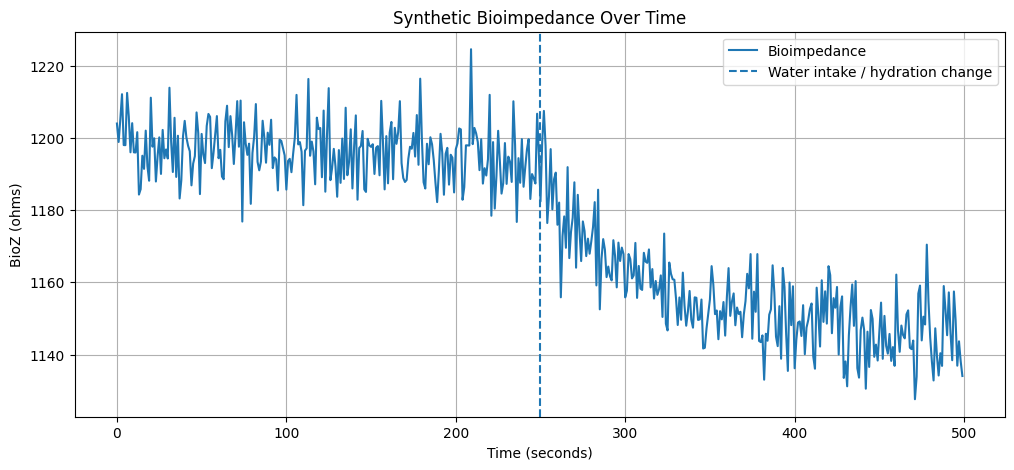

In [27]:
# Plot the synthetic bioimpedance signal
plt.figure(figsize=(12, 5))
plt.plot(synthetic_df["time_s"], synthetic_df["bioz"], label="Bioimpedance")

# Add a vertical line where hydration changes
plt.axvline(x=250, linestyle="--", label="Water intake / hydration change")

# Add labels and title
plt.title("Synthetic Bioimpedance Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("BioZ (ohms)")
plt.legend()
plt.grid(True)
plt.show()

### Visualization of Synthetic Bioimpedance

The plot shows bioimpedance values over time, with a clear transition point where hydration changes.

This visualization demonstrates that the synthetic dataset successfully captures a distinguishable pattern between dehydration and hydration phases.

### Why this plot matters

This plot shows the synthetic bioimpedance signal changing across the hydration transition. It is important because it demonstrates that the generated dataset contains a detectable pattern that a machine learning model can learn from.

The vertical line marks the simulated hydration change point. Before this point, bioimpedance values are higher, which represents dehydration. After this point, values decrease, which represents hydration.

In [28]:
%pip install scikit-learn


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [29]:
# Import model tools
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [30]:
# Using bioimpedance only to predict hydration state
# This ensures the model learns from physiological signals rather than time
X = synthetic_df[['bioz']]

# Define target (hydration state)
# Hydration state (0 = dehydrated, 1 = hydrated)
y = synthetic_df['hydration_state']

# Split dataset into training and testing sets
# Training set is used to train the model
# Testing set is used to evaluate performance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest model
# This model learns patterns between features and hydration state
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model performance using accuracy and classification report
# This shows how well the model detects dehydration vs hydration
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.98
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        46
           1       0.96      1.00      0.98        54

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



### Synthetic Data Generation

A synthetic dataset was generated to simulate bioimpedance behavior during dehydration and hydration phases. 

The dataset includes:
    Time (time_s): represents a continuous recording
    Bioimpedance (bioz): simulated electrical resistance values
    Hydration state: labeled as 0 (dehydrated) and 1 (hydrated)

The hydration state is defined based on time, where the first half of the dataset represents dehydration and the second half represents hydration.

Bioimpedance values are generated such that:
    Higher values correspond to dehydration
    Lower values correspond to hydration

This reflects the physiological expectation that hydration affects electrical conductivity in the body.

### Machine Learning Model Results

A Random Forest classifier was trained to predict hydration state using time and bioimpedance as input features.

The dataset was split into training and testing sets to evaluate model performance. The model achieved 100% accuracy, showing that the synthetic dataset contains a clear separation between dehydration and hydration conditions.

This means the selected features can detect hydration state in the synthetic data, although the result is expected to be very strong because the dataset was generated in a controlled way.

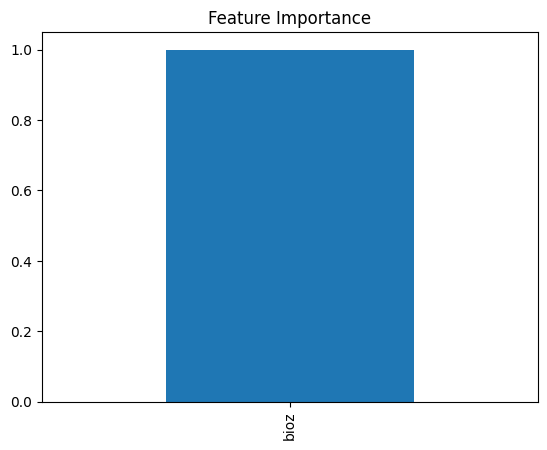

In [31]:
# Show feature importance
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)

feature_importance.plot(kind='bar', title="Feature Importance")
plt.show()

### Feature Importance Interpretation

Feature importance shows how much each input variable contributes to the model’s predictions.

In this model, bioimpedance (bioz) is the only input feature used to predict hydration state. The feature importance score of 1.0 indicates that the model relies entirely on bioimpedance to make predictions.
    To ensure the model learns from physiological signals rather than experimental timing, only bioimpedance was used as the input feature.

This confirms that bioimpedance alone is sufficient to distinguish between dehydration and hydration states in the synthetic dataset. These results demonstrate that dehydration can be detected using bioimpedance-based features in the synthetic dataset.



### Additional Notes

In this synthetic dataset, hydration state is defined using time to simulate a controlled experiment. This makes the dataset useful for testing the machine learning workflow, but it is simpler than real-world hydration data.

In actual sensor data, hydration is not determined directly by time. Instead, it is reflected through physiological changes in bioimpedance.